# **Machine Learning Modeling**

## Import Libraries

In [1]:
# import general python packages 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# import classfiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score


## Import Data 

In [2]:
X_train = pd.read_csv("data/X_train.csv", sep=",", low_memory= False) 
X_test = pd.read_csv("data/X_test.csv", sep=",", low_memory=False)

y_train = pd.read_csv("data/y_train.csv", sep=",", low_memory=False) 
y_test = pd.read_csv("data/y_test.csv", sep=",", low_memory=False) 

# Check lengths 
print(f"X: {len(X_train)}, y: {len(y_train)}")

X: 1524, y: 1524


## Define the Datasets

- **Dataset 1:** Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.
- **Dataset 2:** Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
- **Dataset 3:** Exclude the feature 'Consequence'. Remove missing values in 'Polyphen_Score' and 'SIFT_Score'.
- **Dataset 4:** Exclude the features 'Polyphen_Score', 'SIFT_Score', 'missing_Polyphen', 'missing_SIFT', 'Consequence'.
- **Dataset 5:** Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

## Create Datasets

### Define columns to handle

In [3]:
# Define columns to handle 
score_columns = ["Polyphen_Score", "SIFT_Score"] 
missing_columns = ["missing_Polyphen", "missing_SIFT"] 
consequence_column = ["Consequence"]

### Check column names

In [4]:
# Check column names
print(X_train.columns.tolist())

['Hugo_Symbol', 'Consequence', 'Variant_Type', 'MUTATION_EFFECT', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']


### Dataset 1

In [5]:
# Dataset 1: Full feature set, remove rows with missing values 
mask_train = X_train[score_columns].notna().all(axis=1) 
mask_test = X_test[score_columns].notna().all(axis=1) 

X_train_1 = X_train[mask_train].copy()
y_train_1 = y_train[mask_train].copy()

X_test_1 = X_test[mask_test].copy()
y_test_1 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_1 = X_train_1.drop(columns="Hugo_Symbol")
X_test_1 = X_test_1.drop(columns="Hugo_Symbol") 

# control that no rows has missing values 
print(f"X_train_1 has {(X_train_1.isna().sum().sum())} missing values.") 

X_train_1 has 0 missing values.


In [6]:
print("The five first rows of X_train_1:")  
display(X_train_1.head())

The five first rows of X_train_1:


,Consequence,Variant_Type,MUTATION_EFFECT,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,missense_variant,SNP,Likely Neutral,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP,0
1,missense_variant,SNP,Likely Neutral,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP,0
2,missense_variant,SNP,Likely Neutral,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP,0
3,missense_variant,SNP,Gain-of-function,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP,0
4,missense_variant,SNP,Likely Neutral,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP,0


### Dataset 2

In [7]:
# Dataset 2: Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
cols_to_drop_2 = score_columns + missing_columns 
X_train_2 = X_train.drop(columns=cols_to_drop_2)
X_test_2 = X_test.drop(columns=cols_to_drop_2)
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()

# Drop Hugo_Symbol 
X_train_2 = X_train_2.drop(columns="Hugo_Symbol")
X_test_2 = X_test_2.drop(columns="Hugo_Symbol") 

# Check column names in the new dataset 
print(X_train_2.columns.tolist())

# control that no rows has missing values 
print(f"X_train_2 has {(X_train_2.isna().sum().sum())} missing values.")

['Consequence', 'Variant_Type', 'MUTATION_EFFECT', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_2 has 0 missing values.


In [8]:
print("The five first rows of X_train_2:")  
display(X_train_2.head())

The five first rows of X_train_2:


,Consequence,Variant_Type,MUTATION_EFFECT,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,missense_variant,SNP,Likely Neutral,False,False,False,0,False,0,-6.000000,False_SNP,0
1,missense_variant,SNP,Likely Neutral,True,False,True,1,False,0,-5.301436,False_SNP,0
2,missense_variant,SNP,Likely Neutral,False,False,False,0,False,0,-6.000000,False_SNP,0
3,missense_variant,SNP,Gain-of-function,False,False,True,1,True,1,-6.000000,False_SNP,0
4,missense_variant,SNP,Likely Neutral,True,False,False,0,True,1,-5.047830,False_SNP,0


### Dataset 3 

In [9]:
# Dataset 3: exclude the column 'Consequence', remove missing values in Polyphen and SIFT. 
mask_train = X_train[score_columns].notna().all(axis=1)
mask_test = X_test[score_columns].notna().all(axis=1)

X_train_3 = X_train[mask_train].drop(columns=consequence_column)
X_test_3 = X_test[mask_test].drop(columns=consequence_column)
y_train_3 = y_train[mask_train].copy()
y_test_3 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_3 = X_train_3.drop(columns="Hugo_Symbol")
X_test_3 = X_test_3.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_3.columns.tolist())

# control that no rows has missing values 
print(f"X_train_3 has {(X_train_3.isna().sum().sum())} missing values.")

['Variant_Type', 'MUTATION_EFFECT', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_3 has 0 missing values.


In [10]:
print("The five first rows of X_train_3:")  
display(X_train_3.head())

The five first rows of X_train_3:


,Variant_Type,MUTATION_EFFECT,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,SNP,Likely Neutral,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP,0
1,SNP,Likely Neutral,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP,0
2,SNP,Likely Neutral,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP,0
3,SNP,Gain-of-function,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP,0
4,SNP,Likely Neutral,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP,0


### Dataset 4 

In [11]:
cols_to_drop_4 = score_columns + missing_columns + consequence_column

X_train_4 = X_train.drop(columns=cols_to_drop_4)
X_test_4 = X_test.drop(columns=cols_to_drop_4)
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()

# Drop Hugo_Symbol 
X_train_4 = X_train_4.drop(columns="Hugo_Symbol")
X_test_4 = X_test_4.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_4.columns.tolist())

# control that no rows has missing values 
print(f"X_train_4 has {(X_train_4.isna().sum().sum())} missing values.")  

['Variant_Type', 'MUTATION_EFFECT', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_4 has 0 missing values.


In [12]:
print("The five first rows of X_train_4:")  
display(X_train_4.head())

The five first rows of X_train_4:


,Variant_Type,MUTATION_EFFECT,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,SNP,Likely Neutral,False,False,False,0,False,0,-6.000000,False_SNP,0
1,SNP,Likely Neutral,True,False,True,1,False,0,-5.301436,False_SNP,0
2,SNP,Likely Neutral,False,False,False,0,False,0,-6.000000,False_SNP,0
3,SNP,Gain-of-function,False,False,True,1,True,1,-6.000000,False_SNP,0
4,SNP,Likely Neutral,True,False,False,0,True,1,-5.047830,False_SNP,0


### Dataset 5

In [13]:
# Check which variant types have missing SIFT/Polyphen
print(X_train[X_train['SIFT_Score'].isna()]['Variant_Type'].value_counts())
print(X_train[X_train['Polyphen_Score'].isna()]['Variant_Type'].value_counts())

X_train_5 = X_train.copy()
X_test_5 = X_test.copy()

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_5[impute_cols] = X_train_5[impute_cols].fillna(-1)
X_test_5[impute_cols] = X_test_5[impute_cols].fillna(-1)

y_train_5 = y_train.copy()
y_test_5 = y_test.copy()

# Drop Hugo_Symbol 
X_train_5 = X_train_5.drop(columns="Hugo_Symbol")
X_test_5 = X_test_5.drop(columns="Hugo_Symbol") 

Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64
Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64


In [14]:
# Check for missing values 
print(f"X_train_5 has {X_train_5.isna().sum().sum()} missing values.")

X_train_5 has 0 missing values.


## Define the Pipelines

In [15]:
categorical_feat = ["Variant_Type", "has_gnomAD_AF", "Consequence", "In_Hotspot", "IN_DOMAIN", "IN_FUNC_SITE", 'hotspot_x_vartype', 'MUTATION_EFFECT']

def create_pipeline(df, model, categorical_feat): 
  """
  Creates ML-pipeline based on categorical columns in df, 
  for the chosen ML classifier. 
  """
  existing_cat = [c for c in categorical_feat if c in df.columns]
  existing_num = df.columns.difference(existing_cat).tolist() 

  preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), existing_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), existing_cat)
        ])
  
  return Pipeline([
    ('preprocessor', preprocessor),
    ('clf', model)
  ])

In [16]:
# Define the logistic regression pipeline
pipe_logistic1 = create_pipeline(X_train_1, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic2 = create_pipeline(X_train_2, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic3 = create_pipeline(X_train_3, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic4 = create_pipeline(X_train_4, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic5 = create_pipeline(X_train_5, LogisticRegression(max_iter=5000), categorical_feat)

# Define the random forest pipeline
pipe_rf1 = create_pipeline(X_train_1, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf2 = create_pipeline(X_train_2, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf3 = create_pipeline(X_train_3, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf4 = create_pipeline(X_train_4, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf5 = create_pipeline(X_train_5, RandomForestClassifier(random_state=1), categorical_feat) 


# Define the xgboost pipeline 
pipe_xgb1 = create_pipeline(X_train_1, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb2 = create_pipeline(X_train_2, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb3 = create_pipeline(X_train_3, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb4 = create_pipeline(X_train_4, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb5 = create_pipeline(X_train_5, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)

## **ML Modeling**

## Linear Regression Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [17]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

logistic1 = GridSearchCV(
  estimator=pipe_logistic1, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic2 = GridSearchCV(
  estimator=pipe_logistic2, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic3 = GridSearchCV(
  estimator=pipe_logistic3, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic4 = GridSearchCV(
  estimator=pipe_logistic4, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic5 = GridSearchCV(
  estimator=pipe_logistic5, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)


### Fit logistic model to all training data 

In [18]:
logistic1 = logistic1.fit(X_train_1, y_train_1.values.ravel())

print(f"The best F1-score (Macro) for dataset 1: {logistic1.best_score_}")
print(f"The best hyperparameters: {logistic1.best_params_}")

logistic2 = logistic2.fit(X_train_2, y_train_2.values.ravel())

print(f"The best F1-score (Macro) for dataset 2: {logistic2.best_score_}")
print(f"The best hyperparameters: {logistic2.best_params_}")

logistic3 = logistic3.fit(X_train_3, y_train_3.values.ravel())

print(f"The best F1-score (Macro) for dataset 3: {logistic3.best_score_}")
print(f"The best hyperparameters: {logistic3.best_params_}")

logistic4 = logistic4.fit(X_train_4, y_train_4.values.ravel())

print(f"The best F1-score (Macro) for dataset 4: {logistic4.best_score_}")
print(f"The best hyperparameters: {logistic4.best_params_}")

logistic5 = logistic5.fit(X_train_5, y_train_5.values.ravel())

print(f"The best F1-score (Macro) for dataset 5: {logistic5.best_score_}")
print(f"The best hyperparameters: {logistic5.best_params_}")

The best F1-score (Macro) for dataset 1: 0.9649264648951688
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 2: 0.9721080470474295
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 3: 0.9640857726860818
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 4: 0.9701030978566088
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 5: 0.9727853886544018
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}


### Evaluate Model Performance (Dataset 1)

Evaluates model performance on dataset 1, since this performed best on the training data. 

Dataset 1:
Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.

In [19]:
# Predict classes for dataset 1 
y_pred_1 = logistic1.predict(X_test_1)

# Predict probabilities
y_probs_1 = logistic1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.9679

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       162
           1       0.95      0.99      0.97       150

    accuracy                           0.97       312
   macro avg       0.97      0.97      0.97       312
weighted avg       0.97      0.97      0.97       312



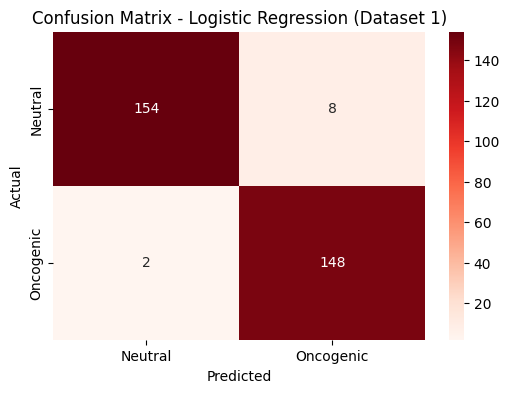

In [20]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 1)')
plt.show()

### Feature Coeffisients for the Logistic Regression Model

In [21]:
best_model = logistic1.best_estimator_  

coefficients = pd.Series(
    best_model.named_steps['clf'].coef_[0],
    index=best_model.named_steps['preprocessor'].get_feature_names_out()
).sort_values(key=abs, ascending=False) 

print(coefficients)

cat__MUTATION_EFFECT_Likely Neutral                       -10.029041
cat__MUTATION_EFFECT_Gain-of-function                       9.114621
cat__MUTATION_EFFECT_Neutral                               -7.155261
cat__MUTATION_EFFECT_Switch-of-function                     3.466472
cat__MUTATION_EFFECT_Loss-of-function                       3.348965
cat__Consequence_missense_variant,splice_region_variant     2.590291
cat__MUTATION_EFFECT_Inconclusive                          -1.919898
num__hotspot_and_func                                       1.525585
cat__IN_DOMAIN_False                                        1.262071
cat__has_gnomAD_AF_True                                    -1.260344
num__n_protein_domains                                     -1.209114
num__n_func_sites                                          -1.105444
cat__In_Hotspot_True                                        0.976297
cat__IN_FUNC_SITE_False                                     0.731745
cat__IN_DOMAIN_True               

## Random Forest Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [22]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

param_dist = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__max_depth': [10, 20, 30, None],
    'clf__criterion': ['gini', 'entropy'],
    'clf__min_samples_split': [2, 5, 10, 12],
    'clf__min_samples_leaf': [1, 2, 4, 6]
}

rf1 = RandomizedSearchCV(
    estimator=pipe_rf1,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf2 = RandomizedSearchCV(
    estimator=pipe_rf2,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf3 = RandomizedSearchCV(
    estimator=pipe_rf3,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf4 = RandomizedSearchCV(
    estimator=pipe_rf4,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf5 = RandomizedSearchCV(
    estimator=pipe_rf5,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

### Fit random forest model to all training data 

In [23]:
rf1 = rf1.fit(X_train_1, y_train_1.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 1: {rf1.best_score_}")
print(f"The best hyperparameters: {rf1.best_params_}")


rf2 = rf2.fit(X_train_2, y_train_2.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 2: {rf2.best_score_}")
print(f"The best hyperparameters: {rf2.best_params_}")


rf3 = rf3.fit(X_train_3, y_train_3.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 3: {rf3.best_score_}")
print(f"The best hyperparameters: {rf3.best_params_}")


rf4 = rf4.fit(X_train_4, y_train_4.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 4: {rf4.best_score_}")
print(f"The best hyperparameters: {rf4.best_params_}")


rf5 = rf5.fit(X_train_5, y_train_5.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 5: {rf5.best_score_}")
print(f"The best hyperparameters: {rf5.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 1: 0.9682382768445782
The best hyperparameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 12, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__criterion': 'entropy'}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 2: 0.9701390173852807
The best hyperparameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 30, 'clf__criterion': 'entropy'}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 3: 0.9690717829314146
The best hyperparameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 12, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20, 'clf__criterion': 'entropy'}
Fitting 10 folds for each of 20 candidates, totalling 200

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [24]:
# Predict classes for dataset 5
y_pred_5 = rf5.predict(X_test_5)

# Predict probabilities
y_probs_5 = rf5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       172
           1       0.94      0.99      0.96       210

    accuracy                           0.96       382
   macro avg       0.96      0.95      0.95       382
weighted avg       0.96      0.96      0.96       382



Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Dataset 3)')

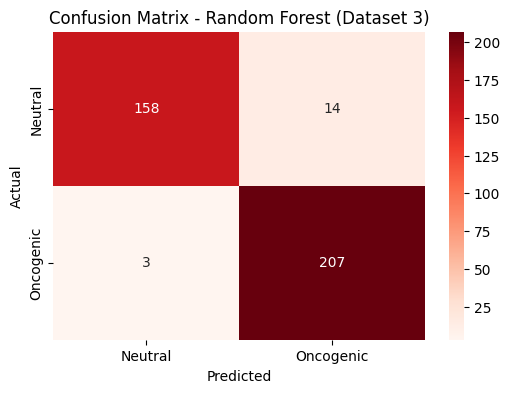

In [25]:
cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 3)')

### Feature importances Random Forest 

In [26]:
# Define the best model 
best_model = rf5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Likely Neutral                                0.376242
cat__MUTATION_EFFECT_Gain-of-function                              0.165061
cat__MUTATION_EFFECT_Loss-of-function                              0.073222
num__Polyphen_Score                                                0.041010
cat__MUTATION_EFFECT_Likely Loss-of-function                       0.037728
num__SIFT_Score                                                    0.035140
cat__hotspot_x_vartype_False_SNP                                   0.034270
cat__In_Hotspot_False                                              0.024877
cat__In_Hotspot_True                                               0.020238
cat__MUTATION_EFFECT_Neutral                                       0.019551
cat__hotspot_x_vartype_True_SNP                                    0.019354
num__gnomAD_AF_log                                                 0.016877
cat__MUTATION_EFFECT_Likely Gain-of-function                       0.010530
num__n_func_

## XGBoost Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [27]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

xgb_param_dist = {
    'clf__n_estimators': [100, 300, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7, 9],
    'clf__subsample': [0.7, 0.8, 0.9],
    'clf__colsample_bytree': [0.7, 0.8, 0.9],
    'clf__gamma': [0, 0.1, 0.5, 1],
    'clf__scale_pos_weight': [0.7,0.8,0.9,1,3,5] 
}

xgb1 = RandomizedSearchCV(
        estimator=pipe_xgb1,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb2 = RandomizedSearchCV(
        estimator=pipe_xgb2,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb3 = RandomizedSearchCV(
        estimator=pipe_xgb3,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb4 = RandomizedSearchCV(
        estimator=pipe_xgb4,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb5 = RandomizedSearchCV(
        estimator=pipe_xgb5,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )


In [28]:
xgb1 = xgb1.fit(X_train_1, y_train_1.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 1: {xgb1.best_score_}")
print(f"The best hyperparameters: {xgb1.best_params_}")


xgb2 = xgb2.fit(X_train_2, y_train_2.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 2: {xgb2.best_score_}")
print(f"The best hyperparameters: {xgb2.best_params_}")


xgb3 = xgb3.fit(X_train_3, y_train_3.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 3: {xgb3.best_score_}")
print(f"The best hyperparameters: {xgb3.best_params_}")


xgb4 = xgb4.fit(X_train_4, y_train_4.values.ravel()) 


print(f"The best F1-score (Macro) for dataset 4: {xgb4.best_score_}")
print(f"The best hyperparameters: {xgb4.best_params_}")


xgb5 = xgb5.fit(X_train_5, y_train_5.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 5: {xgb5.best_score_}")
print(f"The best hyperparameters: {xgb5.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 1: 0.9648968794608438
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.7}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 2: 0.9734438475168645
The best hyperparameters: {'clf__subsample': 0.7, 'clf__scale_pos_weight': 0.9, 'clf__n_estimators': 500, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.9}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 3: 0.9648968794608438
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.7}
Fitting 10 folds for each

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5. Dataset 1 performs slightly better on the training data (0.003), but was trained on a smaller sample size. Since dataset 5 retains more data, this will be used for evaluation on test data. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [29]:
# Predict classes for dataset 5
y_pred_5 = xgb5.predict(X_test_5)

# Predict probabilities
y_probs_5 = xgb5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.9576

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       172
           1       0.95      0.98      0.96       210

    accuracy                           0.96       382
   macro avg       0.96      0.96      0.96       382
weighted avg       0.96      0.96      0.96       382



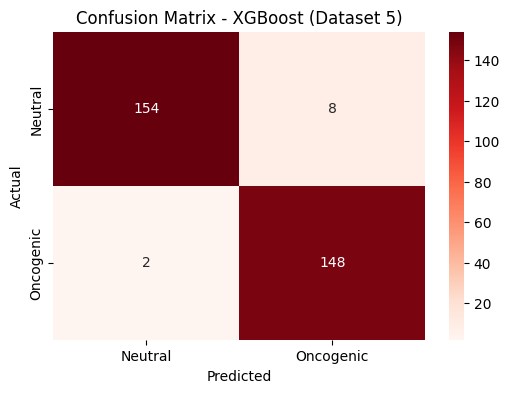

In [30]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 5)')
plt.show()

### Feature Importances XGBoost

In [31]:
# Define the best model 
best_model = xgb1.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Likely Neutral                        0.480546
cat__MUTATION_EFFECT_Gain-of-function                      0.106496
cat__MUTATION_EFFECT_Loss-of-function                      0.074541
cat__MUTATION_EFFECT_Neutral                               0.057417
cat__In_Hotspot_False                                      0.042751
cat__In_Hotspot_True                                       0.042455
cat__MUTATION_EFFECT_Likely Loss-of-function               0.037044
cat__hotspot_x_vartype_True_SNP                            0.029124
cat__IN_DOMAIN_True                                        0.026079
cat__IN_DOMAIN_False                                       0.017065
num__n_protein_domains                                     0.016317
cat__has_gnomAD_AF_True                                    0.009535
cat__has_gnomAD_AF_False                                   0.008406
cat__MUTATION_EFFECT_Likely Gain-of-function               0.008299
cat__IN_FUNC_SITE_True                          

## **Run Best Model (xgb5) on Selected Top Oncogenic Genes**

## TP53 dataset 

### Define the data

In [32]:
X_train_TP53 = X_train[X_train["Hugo_Symbol"] == 'TP53']
X_test_TP53 = X_test[X_test["Hugo_Symbol"] == 'TP53']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_TP53[impute_cols] = X_train_TP53[impute_cols].fillna(-1)
X_test_TP53[impute_cols] = X_test_TP53[impute_cols].fillna(-1)

X_train_TP53 = X_train_TP53.drop(columns="Hugo_Symbol")
X_test_TP53 = X_test_TP53.drop(columns="Hugo_Symbol")

# Filter y to match TP53 indices
y_train_TP53 = y_train.loc[X_train_TP53.index]
y_test_TP53 = y_test.loc[X_test_TP53.index]

### Fit model to data

In [33]:
xgb5_TP53 = xgb5.fit(X_train_TP53, y_train_TP53.values.ravel()) 

print(xgb5_TP53.best_score_)
print(xgb5_TP53.best_params_)

print(f"The best F1-score (Macro) for the TP53 dataset: {xgb5_TP53.best_score_}")
print(f"The best hyperparameters: {xgb5_TP53.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
1.0
{'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}
The best F1-score (Macro) for the TP53 dataset: 1.0
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}


### Predict classes and make classification report

In [34]:
# Predict classes for the TP53 dataset
y_pred_TP53 = xgb5_TP53.predict(X_test_TP53)

# Predict probabilities
y_probs_TP53 = xgb5_TP53.predict_proba(X_test_TP53)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_TP53, y_pred_TP53, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_TP53, y_pred_TP53))

Test F1-score (Macro): 0.9091

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.83      0.91         6

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11



### Create confusion matrix

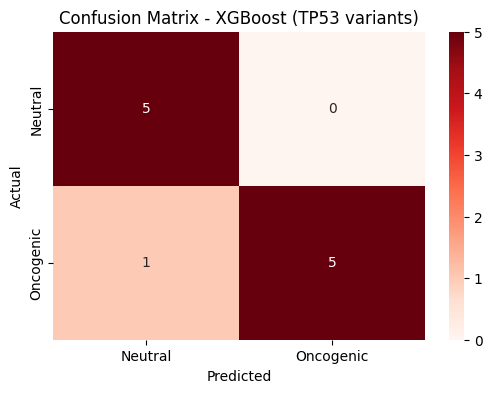

In [35]:
cm = confusion_matrix(y_test_TP53, y_pred_TP53)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (TP53 variants)')
plt.show()

### Find feature importances

In [36]:
# Define the best model 
best_model_TP53 = xgb5_TP53.best_estimator_

# Get feature names 
feature_names = best_model_TP53.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_TP53.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Loss-of-function           0.337120
cat__MUTATION_EFFECT_Likely Neutral             0.275041
num__Polyphen_Score                             0.138832
num__SIFT_Score                                 0.137277
num__hotspot_and_func                           0.111729
num__missing_SIFT                               0.000000
num__missing_Polyphen                           0.000000
num__gnomAD_AF_log                              0.000000
num__n_protein_domains                          0.000000
num__n_func_sites                               0.000000
cat__Variant_Type_SNP                           0.000000
cat__has_gnomAD_AF_False                        0.000000
cat__In_Hotspot_False                           0.000000
cat__In_Hotspot_True                            0.000000
cat__has_gnomAD_AF_True                         0.000000
cat__Consequence_missense_variant               0.000000
cat__IN_DOMAIN_True                             0.000000
cat__IN_DOMAIN_False           

## EGFR dataset

### Define the data

In [37]:
X_train_EGFR = X_train[X_train["Hugo_Symbol"] == 'EGFR']
X_test_EGFR = X_test[X_test["Hugo_Symbol"] == 'EGFR']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_EGFR[impute_cols] = X_train_EGFR[impute_cols].fillna(-1)
X_test_EGFR[impute_cols] = X_test_EGFR[impute_cols].fillna(-1)

X_train_EGFR = X_train_EGFR.drop(columns="Hugo_Symbol")
X_test_EGFR = X_test_EGFR.drop(columns="Hugo_Symbol")

# Filter y to match EGFR indices
y_train_EGFR = y_train.loc[X_train_EGFR.index]
y_test_EGFR = y_test.loc[X_test_EGFR.index]

### Fit model to data

In [38]:
xgb5_EGFR = xgb5.fit(X_train_EGFR, y_train_EGFR.values.ravel()) 

print(xgb5_EGFR.best_score_)
print(xgb5_EGFR.best_params_)

print(f"The best F1-score (Macro) for the EGFR dataset: {xgb5_EGFR.best_score_}")
print(f"The best hyperparameters: {xgb5_EGFR.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.9883116883116884
{'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}
The best F1-score (Macro) for the EGFR dataset: 0.9883116883116884
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}


### Predict classes and make classification report

In [39]:
# Predict classes for the EGFR dataset
y_pred_EGFR = xgb5_EGFR.predict(X_test_EGFR)

# Predict probabilities
y_probs_EGFR = xgb5_EGFR.predict_proba(X_test_EGFR)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_EGFR, y_pred_EGFR, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_EGFR, y_pred_EGFR))

Test F1-score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



### Create confusion matrix

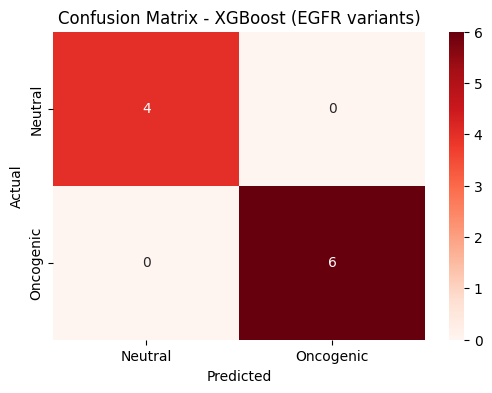

In [40]:
cm = confusion_matrix(y_test_EGFR, y_pred_EGFR)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (EGFR variants)')
plt.show()

### Find feature importances

In [41]:
# Define the best model 
best_model_EGFR = xgb5_EGFR.best_estimator_

# Get feature names 
feature_names = best_model_EGFR.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_EGFR.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Likely Neutral                        0.302199
cat__MUTATION_EFFECT_Gain-of-function                      0.218455
cat__MUTATION_EFFECT_Likely Gain-of-function               0.111405
num__SIFT_Score                                            0.089565
cat__MUTATION_EFFECT_Likely Loss-of-function               0.082977
cat__hotspot_x_vartype_False_SNP                           0.041987
cat__has_gnomAD_AF_False                                   0.037840
num__Polyphen_Score                                        0.037036
num__missing_SIFT                                          0.035192
num__gnomAD_AF_log                                         0.021840
num__n_protein_domains                                     0.021504
cat__Variant_Type_DNP                                      0.000000
cat__Variant_Type_SNP                                      0.000000
cat__Variant_Type_INS                                      0.000000
num__missing_Polyphen                           

## BRAF dataset

### Define the data

In [42]:
X_train_BRAF = X_train[X_train["Hugo_Symbol"] == 'BRAF']
X_test_BRAF = X_test[X_test["Hugo_Symbol"] == 'BRAF']

X_train_BRAF[impute_cols] = X_train_BRAF[impute_cols].fillna(-1)
X_test_BRAF[impute_cols] = X_test_BRAF[impute_cols].fillna(-1)

X_train_BRAF = X_train_BRAF.drop(columns="Hugo_Symbol")
X_test_BRAF = X_test_BRAF.drop(columns="Hugo_Symbol")

# Filter to match BRAF indices 
y_train_BRAF = y_train.loc[X_train_BRAF.index]
y_test_BRAF = y_test.loc[X_test_BRAF.index]

### Fit model to data

In [43]:
xgb5_BRAF = xgb5.fit(X_train_BRAF, y_train_BRAF.values.ravel()) 

print(xgb5_BRAF.best_score_)
print(xgb5_BRAF.best_params_)

print(f"The best F1-score (Macro) for the BRAF dataset: {xgb5_BRAF.best_score_}")
print(f"The best hyperparameters: {xgb5_BRAF.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits


1.0
{'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}
The best F1-score (Macro) for the BRAF dataset: 1.0
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}


### Predict classes and make classification report

In [44]:
# Predict classes for the BRAF dataset
y_pred_BRAF = xgb5_BRAF.predict(X_test_BRAF)

# Predict probabilities
y_probs_BRAF = xgb5_BRAF.predict_proba(X_test_BRAF)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_BRAF, y_pred_BRAF, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_BRAF, y_pred_BRAF))

Test F1-score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         9

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



### Create confusion matrix

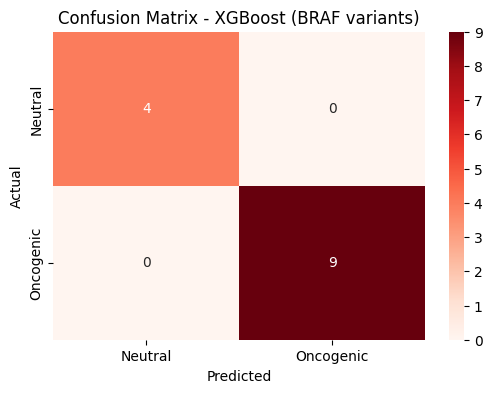

In [45]:
cm = confusion_matrix(y_test_BRAF, y_pred_BRAF)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (BRAF variants)')
plt.show()

### Find feature importances

In [46]:
# Define the best model 
best_model_BRAF = xgb5_BRAF.best_estimator_

# Get feature names 
feature_names = best_model_BRAF.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_BRAF.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Gain-of-function                      0.416918
cat__MUTATION_EFFECT_Likely Loss-of-function               0.245462
cat__MUTATION_EFFECT_Likely Neutral                        0.214926
num__SIFT_Score                                            0.066208
cat__hotspot_x_vartype_False_SNP                           0.056486
num__gnomAD_AF_log                                         0.000000
num__Polyphen_Score                                        0.000000
num__hotspot_and_func                                      0.000000
num__missing_Polyphen                                      0.000000
num__missing_SIFT                                          0.000000
num__n_func_sites                                          0.000000
cat__Variant_Type_ONP                                      0.000000
cat__Variant_Type_SNP                                      0.000000
cat__has_gnomAD_AF_False                                   0.000000
cat__has_gnomAD_AF_True                         

## ERBB2 dataset 

### Define the data

In [47]:
X_train_ERBB2 = X_train[X_train["Hugo_Symbol"] == 'ERBB2']
X_test_ERBB2 = X_test[X_test["Hugo_Symbol"] == 'ERBB2']

X_train_ERBB2[impute_cols] = X_train_ERBB2[impute_cols].fillna(-1)
X_test_ERBB2[impute_cols] = X_test_ERBB2[impute_cols].fillna(-1)

X_train_ERBB2 = X_train_ERBB2.drop(columns="Hugo_Symbol")
X_test_ERBB2 = X_test_ERBB2.drop(columns="Hugo_Symbol")

# Filter to match ERBB2 indices 
y_train_ERBB2 = y_train.loc[X_train_ERBB2.index]
y_test_ERBB2 = y_test.loc[X_test_ERBB2.index]

### Fit model to data

In [48]:
xgb5_ERBB2 = xgb5.fit(X_train_ERBB2, y_train_ERBB2.values.ravel()) 

print(xgb5_ERBB2.best_score_)
print(xgb5_ERBB2.best_params_)

print(f"The best F1-score (Macro) for the ERBB2 dataset: {xgb5_ERBB2.best_score_}")
print(f"The best hyperparameters: {xgb5_ERBB2.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.9828571428571429
{'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}
The best F1-score (Macro) for the ERBB2 dataset: 0.9828571428571429
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 0.9}


### Predict classes and make classification report

In [49]:
# Predict classes for the ERBB2 dataset
y_pred_ERBB2 = xgb5_ERBB2.predict(X_test_ERBB2)

# Predict probabilities
y_probs_ERBB2 = xgb5_ERBB2.predict_proba(X_test_ERBB2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_ERBB2, y_pred_ERBB2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_ERBB2, y_pred_ERBB2))

Test F1-score (Macro): 0.9282

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.88      1.00      0.93         7

    accuracy                           0.93        14
   macro avg       0.94      0.93      0.93        14
weighted avg       0.94      0.93      0.93        14



### Create confusion matrix

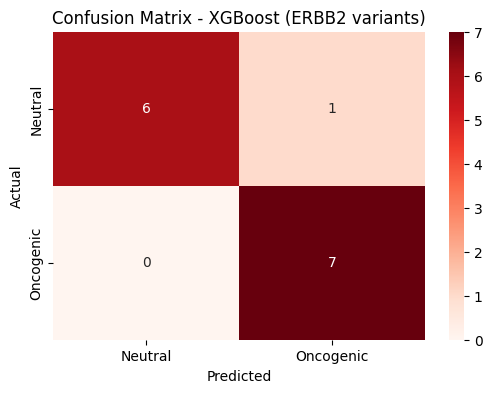

In [50]:
cm = confusion_matrix(y_test_ERBB2, y_pred_ERBB2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (ERBB2 variants)')
plt.show()

### Find feature importances

In [51]:
# Define the best model 
best_model_ERBB2 = xgb5_ERBB2.best_estimator_

# Get feature names 
feature_names = best_model_ERBB2.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_ERBB2.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__MUTATION_EFFECT_Likely Neutral                        0.469544
cat__MUTATION_EFFECT_Likely Gain-of-function               0.201761
cat__MUTATION_EFFECT_Gain-of-function                      0.193942
cat__hotspot_x_vartype_False_SNP                           0.110165
num__Polyphen_Score                                        0.024588
num__gnomAD_AF_log                                         0.000000
num__SIFT_Score                                            0.000000
num__hotspot_and_func                                      0.000000
num__missing_Polyphen                                      0.000000
num__missing_SIFT                                          0.000000
num__n_func_sites                                          0.000000
cat__Variant_Type_ONP                                      0.000000
cat__Variant_Type_SNP                                      0.000000
cat__has_gnomAD_AF_False                                   0.000000
cat__has_gnomAD_AF_True                         